# Retail Sales – Exploratory Data Analysis (EDA) and Simple ML

## Introduction & Problem Statement

- Dataset: supermarket / retail sales data (each row is a customer transaction).
- Example fields: city, customer type, product line, unit price, quantity, tax, total, date, time, payment method.
- Objective:
  - Understand which product lines and cities generate the most revenue.
  - Analyse sales patterns over time.
  - Build a simple model to predict total sales or classify high-sales transactions.
- Why it matters:
  - Helps retail teams plan inventory, marketing, and staffing decisions.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load Libraries & Data

In [12]:
from google.colab import files
import io

uploaded = files.upload()  # choose your sales CSV
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()

Saving supermarket_sales.csv to supermarket_sales (2).csv


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## Basic Info & Data Cleaning

In this section, we:
- Inspect the structure of the dataset.
- Check data types and missing values.
- Apply basic cleaning: type conversions, handling missing values, and removing duplicates if needed.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice ID,1000,1000,849-09-3807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,1000,3,Alex,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,3,Yangon,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer type,1000,2,Member,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product line,1000,6,Fashion accessories,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit price,1000.0,NaN,NaN,NaN,55.67213,26.494628,10.08,32.875,55.23,77.935,99.96
Quantity,1000.0,NaN,NaN,NaN,5.51,2.923431,1.0,3.0,5.0,8.0,10.0
Tax 5%,1000.0,NaN,NaN,NaN,15.379369,11.708825,0.5085,5.924875,12.088,22.44525,49.65
Sales,1000.0,NaN,NaN,NaN,322.966749,245.885335,10.6785,124.422375,253.848,471.35025,1042.65


In [15]:
# Shape and missing values
print("Shape:", df.shape)
df.isna().sum()

Shape: (1000, 17)


,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [16]:
# Convert Date column to datetime (adjust the column name if needed)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'].head()

,Date
0,2019-01-05
1,2019-03-08
2,2019-03-03
3,2019-01-27
4,2019-02-08


In [17]:
# Remove duplicate rows (if any)
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Dropped {before - after} duplicate rows")

Dropped 0 duplicate rows


### Cleaning summary

- Converted the `Date` column to datetime type.
- Checked for missing values and duplicates.
- Dropped exact duplicate rows to keep the dataset clean.

## Exploratory Data Analysis (EDA)

In this section, we explore:

- Overall distribution of sales amounts.
- Sales across categories (like product line, city, customer type).
- Simple relationships between key numeric features.

The goal is to understand where most revenue comes from and what patterns exist in the data.

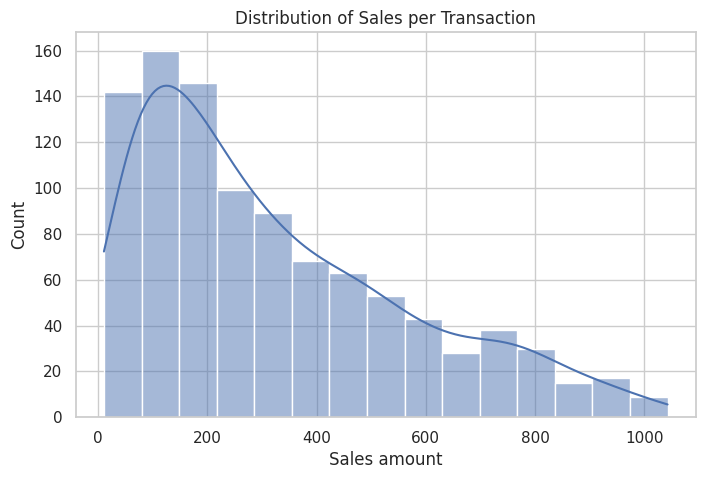

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales per Transaction')
plt.xlabel('Sales amount')
plt.ylabel('Count')
plt.show()

### Observation: Sales distribution

- Describe whether most transactions have low or medium sales, and if there are a few very high-sales transactions.
- Mention if the distribution is skewed.

In [22]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

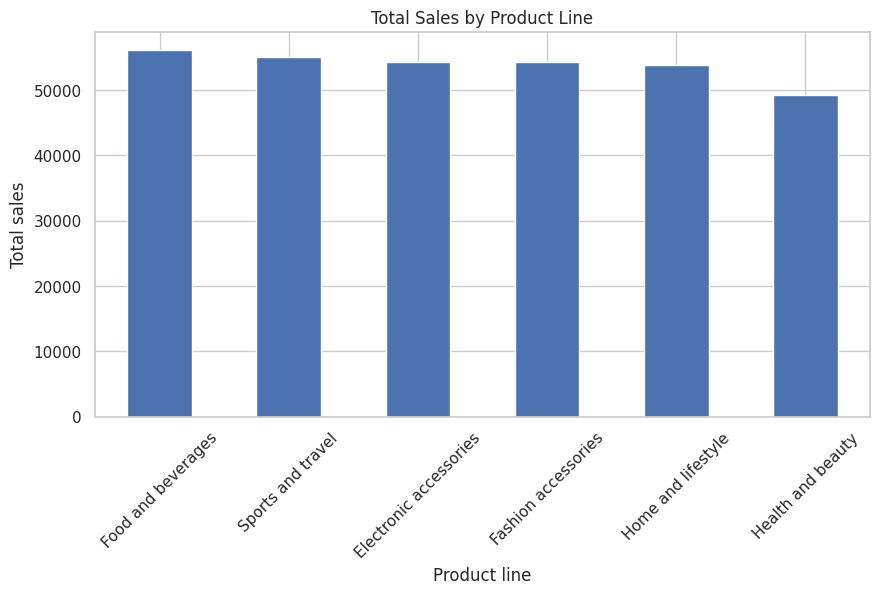

In [23]:
plt.figure(figsize=(10, 5))
df.groupby('Product line')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by Product Line')
plt.ylabel('Total sales')
plt.xlabel('Product line')
plt.xticks(rotation=45)
plt.show()

### Observation: Sales by product line

- Mention which product lines generate the highest total sales.
- Note any product line with much lower sales than the others.

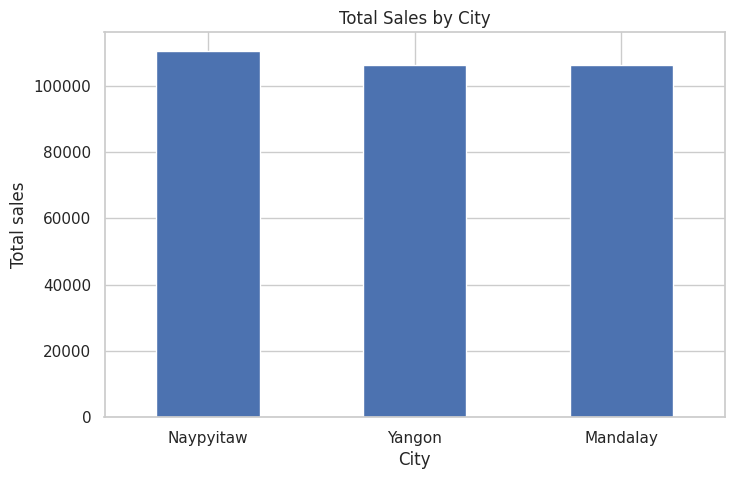

In [24]:
plt.figure(figsize=(8, 5))
df.groupby('City')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by City')
plt.ylabel('Total sales')
plt.xlabel('City')
plt.xticks(rotation=0)
plt.show()

### Observation: Sales by city

- State which city has the highest total sales.
- Comment if the differences between cities are large or relatively similar.

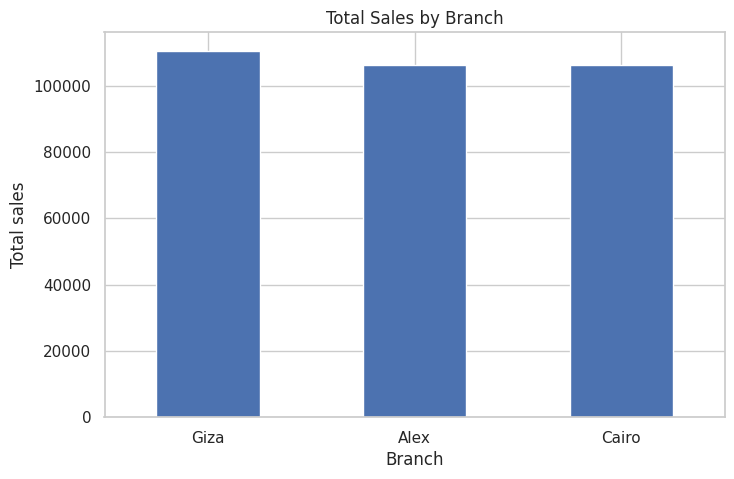

In [25]:
plt.figure(figsize=(8, 5))
df.groupby('Branch')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by Branch')
plt.ylabel('Total sales')
plt.xlabel('Branch')
plt.xticks(rotation=0)
plt.show()

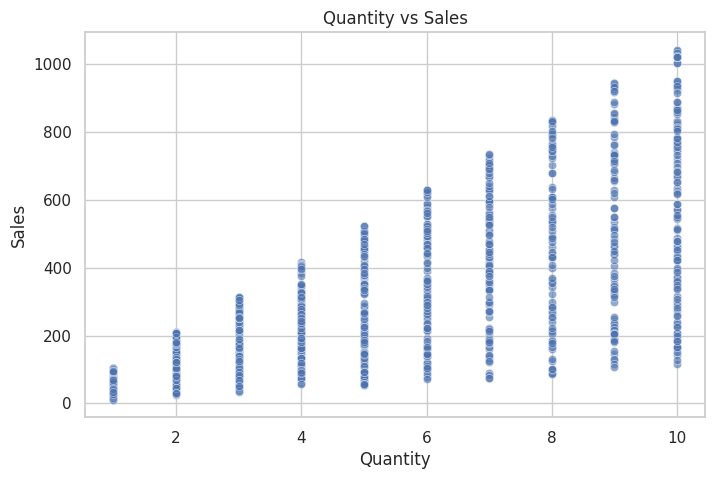

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Quantity', y='Sales', alpha=0.6)
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.show()

### Observation: Quantity vs sales

- Comment on whether higher quantities usually lead to higher sales.
- Note any points where quantity is high but sales are not very high (or vice versa).

## Simple ML Model (Prediction)

In this section, we build a simple regression model to predict `Sales` for each transaction.

- Target variable: `Sales`.
- Example features: branch, city, customer type, gender, product line, unit price, quantity, rating.
- Goal: show a basic end-to-end ML workflow (preprocessing, train-test split, model training, evaluation).


In [29]:
# Target variable
y = df['Sales']

# Feature columns we will use
feature_cols = ['Branch', 'City', 'Customer type', 'Gender',
                'Product line', 'Unit price', 'Quantity', 'Rating']

X = df[feature_cols]
X.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Rating
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,9.1
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,9.6
2,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,7.4
3,Alex,Yangon,Member,Female,Health and beauty,58.22,8,8.4
4,Alex,Yangon,Member,Female,Sports and travel,86.31,7,5.3


In [30]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,Unit price,Quantity,Rating,Branch_Cairo,Branch_Giza,City_Naypyitaw,City_Yangon,Customer type_Normal,Gender_Male,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel
0,74.69,7,9.1,False,False,False,True,False,False,False,False,True,False,False
1,15.28,5,9.6,False,True,True,False,True,False,False,False,False,False,False
2,46.33,7,7.4,False,False,False,True,True,False,False,False,False,True,False
3,58.22,8,8.4,False,False,False,True,False,False,False,False,True,False,False
4,86.31,7,5.3,False,False,False,True,False,False,False,False,False,False,True


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((800, 14), (200, 14))

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

rmse, r2

(79.94504952677892, 0.9017628564675392)

### Model performance

- Root Mean Squared Error (RMSE): **79.95**
- R² score: **0.90**

The RMSE of around 80 means that, on average, the model's predictions differ from the actual `Sales` values by about 80 currency units per transaction.  
An R² of 0.90 indicates that the model explains roughly 90% of the variance in `Sales`, which is strong performance for a simple baseline regression model on this dataset.

## Key Findings & Business Recommendations

### Key findings

- Across product lines, total sales are relatively balanced, with no single product line clearly dominating or clearly underperforming in the dataset. This suggests a diversified revenue distribution across categories.
- Sales by city/branch are also fairly similar in magnitude, indicating that all locations contribute meaningfully to overall revenue rather than one city/branch heavily driving sales.
- The Quantity vs Sales plot shows an overall upward pattern: as quantity increases, sales generally increase as well. This matches expectations, since higher quantities per transaction naturally lead to higher sales amounts.
- The regression model predicting `Sales` achieves an RMSE of around **80** and an R² of about **0.90**, meaning it explains roughly 90% of the variation in transaction-level sales with a moderate average error.



### Business recommendations

- Since product lines generate similar levels of sales, the supermarket can continue to maintain a broad assortment while running targeted experiments (promotions, cross-selling) to see if any category can be boosted further.
- Because all cities/branches contribute meaningfully to revenue, management should monitor each location closely and use local marketing or offers rather than focusing only on one "top" city.
- The positive relationship between quantity and sales suggests that strategies encouraging customers to buy slightly higher quantities (bundles, volume discounts, combo offers) could increase total revenue.
- The current regression model can serve as a baseline sales prediction tool. Future work could incorporate time-based features (day of week, time of day, month) and more advanced models to further improve forecasting accuracy.